In [35]:
"""
Complete Data Analysis Script
Dataset: customer_retention.csv  (7,043 rows × 21 cols)
Libraries: Pandas, NumPy, Plotly
The goal is:

"Understand which customers leave, why they leave, and which factors influence retention."
"""

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)
print("Libraries Imported Successfully")




Libraries Imported Successfully


In [16]:
# CELL 2 — Load Dataset
# ─────────────────────────────────────────────
df = pd.read_csv('customer_retention.csv')
print("Dataset Loaded Successfully")


#print("Missing Values:\n", df.isnull().sum())


Dataset Loaded Successfully


In [7]:
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())


Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [9]:
# Basic Info & Data Types
print(df.info())
print("\nDescribe:\n", df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
# Check & Fix Missing Values
# TotalCharges is stored as string (has blank spaces)
# → convert to numeric, fill NaN with median
# ─────────────────────────────────────────────
print("Missing Values:\n", df.isnull().sum())
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("\nAfter Fixing TotalCharges:\n", df.isnull().sum())


Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_Num           0
dtype: int64

After Fixing TotalCharges:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn            

In [27]:
#  6 — Value Counts
# ─────────────────────────────────────────────
print("Contract Distribution:\n",      df['Contract'].value_counts())
print("\nChurn Distribution:\n",        df['Churn'].value_counts())
print("\nInternetService Distribution:\n", df['InternetService'].value_counts())
print("\nPaymentMethod Distribution:\n",   df['PaymentMethod'].value_counts())

Contract Distribution:
 Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Churn Distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

InternetService Distribution:
 InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

PaymentMethod Distribution:
 PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [28]:
#— Encode 'Churn' for numeric use
# ─────────────────────────────────────────────
df['Churn_Num'] = df['Churn'].map({'Yes': 1, 'No': 0})

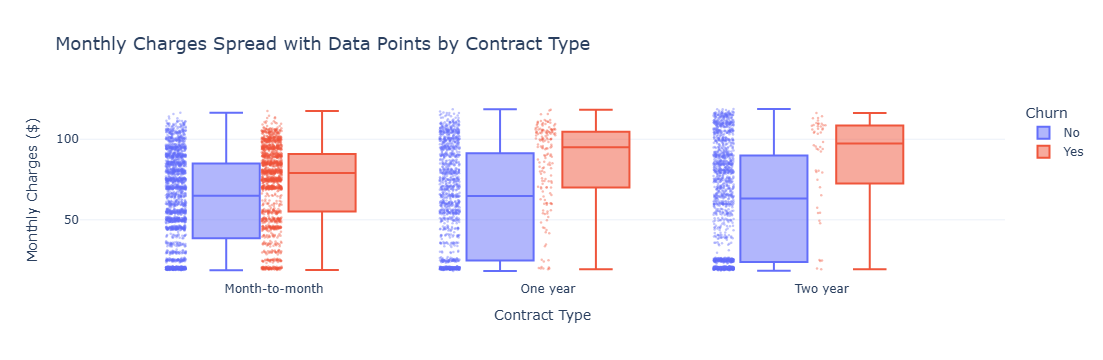

In [29]:
# CELL 8 — Box Plot: Monthly Charges spread by Contract
# (Equivalent to "ROI Spread with Data Points" in video)
# ─────────────────────────────────────────────
fig_box = px.box(
    df,
    x='Contract',
    y='MonthlyCharges',
    color='Churn',
    points='all',               # show all data points like video
    title='Monthly Charges Spread with Data Points by Contract Type',
    color_discrete_map={'Yes': '#EF553B', 'No': '#636EFA'},
    template='plotly_white',
    hover_data=['tenure', 'InternetService']
)
fig_box.update_layout(
    title_font_size=18,
    xaxis_title='Contract Type',
    yaxis_title='Monthly Charges ($)',
)
fig_box.update_traces(marker=dict(size=2.5, opacity=0.4))
fig_box.show()
# fig_box.write_html('boxplot_monthly_charges.html')


In [36]:
#— Pivot Table
# ─────────────────────────────────────────────
pivot_table = df.pivot_table(
    values='MonthlyCharges',
    index='Contract',
    columns='Churn',
    aggfunc='mean'
).round(2)
print("\nPivot Table — Mean Monthly Charges by Contract & Churn:\n", pivot_table)


Pivot Table — Mean Monthly Charges by Contract & Churn:
 Churn              No    Yes
Contract                    
Month-to-month  61.46  73.02
One year        62.51  85.05
Two year        60.01  86.78


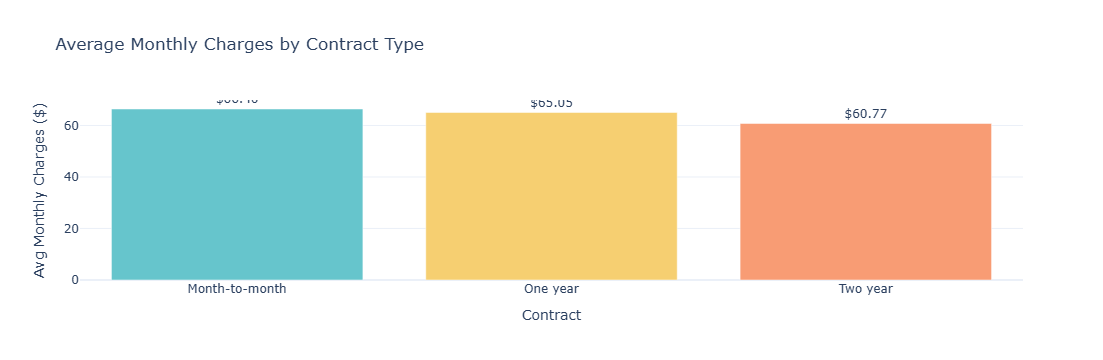

In [31]:
#  — Bar Chart: Avg Monthly Charges by Contract
# ─────────────────────────────────────────────
avg_charges = df.groupby('Contract')['MonthlyCharges'].mean().reset_index()

fig_bar = px.bar(
    avg_charges,
    x='Contract',
    y='MonthlyCharges',
    color='Contract',
    title='Average Monthly Charges by Contract Type',
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    text='MonthlyCharges'
)
fig_bar.update_traces(texttemplate='$%{text:.2f}', textposition='outside')
fig_bar.update_layout(yaxis_title='Avg Monthly Charges ($)', showlegend=False)
fig_bar.show()

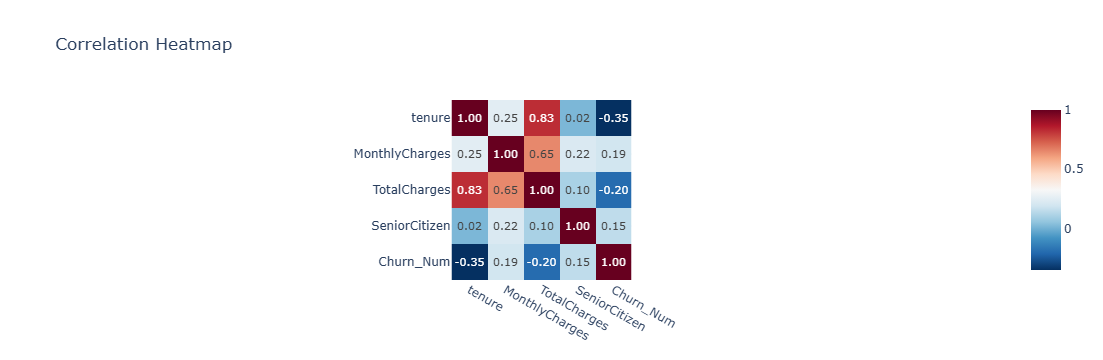

In [32]:
# CELL 11 — Correlation Heatmap (numeric cols)
# ─────────────────────────────────────────────
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_Num']]
corr = numeric_df.corr()

fig_heat = px.imshow(
    corr,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Correlation Heatmap',
    template='plotly_white'
)
fig_heat.show()

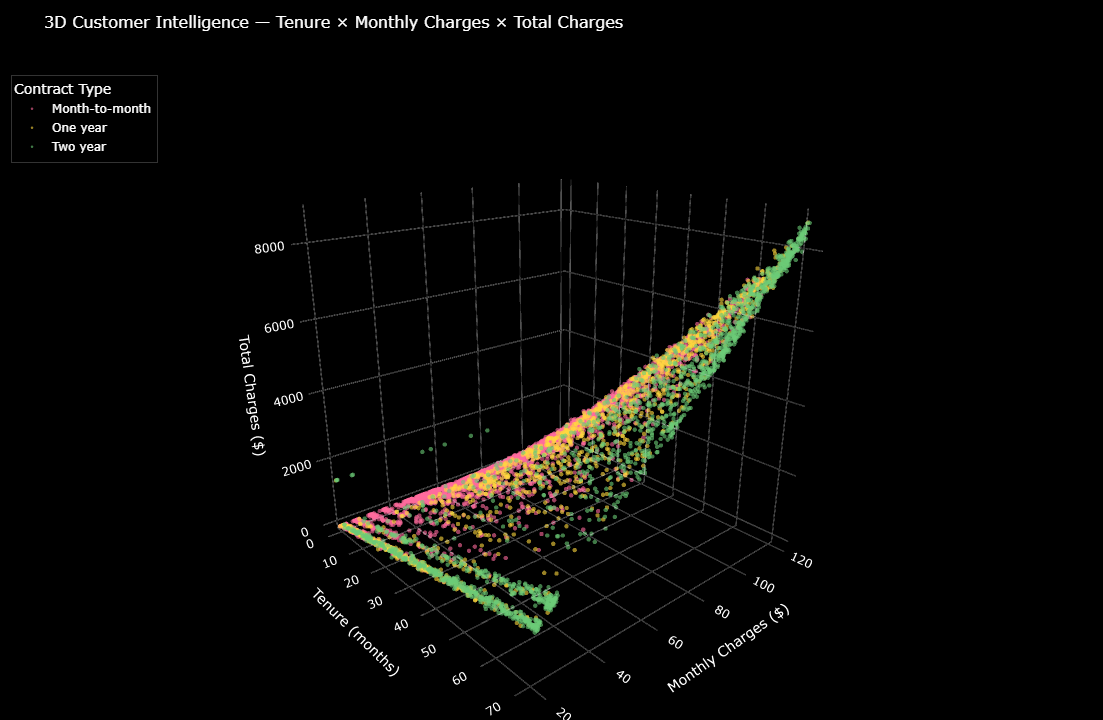

In [33]:
#  — ★ 3D SCATTER PLOT ★  (The hero chart from the video)
#
# VIDEO BREAKDOWN:
#   Axes  → X: ROI  | Y: Acquisition_Cost  | Z: Engagement_Rate
#   Color → Campaign_Type (categorical)
#   Size  → small uniform dots
#   BG    → pure black (paper_bgcolor + plot_bgcolor)
#   Glow  → achieved by opacity (semi-transparent markers)
#   Grid  → thin white lines
#
# THIS DATASET mapping:
#   X: tenure            (how long they've been a customer — 0–72 months)
#   Y: MonthlyCharges    (what they pay per month — $18–$119)
#   Z: TotalCharges      (lifetime value — TotalCharges ≈ tenure × Monthly)
#   Color: Contract      (categorical — Month-to-month / One year / Two year)
#   Size: uniform small dots
# ─────────────────────────────────────────────────────────────────────────────

# Color map per Contract type — vibrant like video
color_map = {
    'Month-to-month': '#FF6B9D',   # hot pink
    'One year':       '#FFD93D',   # golden yellow
    'Two year':       '#6BCB77',   # mint green
}

fig_3d = go.Figure()

for contract, grp in df.groupby('Contract'):
    fig_3d.add_trace(go.Scatter3d(
        x=grp['tenure'],
        y=grp['MonthlyCharges'],
        z=grp['TotalCharges'],
        mode='markers',
        name=contract,
        marker=dict(
            size=2.5,                              # small dots like video
            color=color_map.get(contract, '#ffffff'),
            opacity=0.60,                          # semi-transparent → glow effect
            line=dict(width=0),                    # no border on dots
        ),
        hovertemplate=(
            '<b>%{fullData.name}</b><br>'
            'Tenure : %{x} months<br>'
            'Monthly: $%{y:.2f}<br>'
            'Total  : $%{z:,.0f}<br>'
            '<extra></extra>'
        )
    ))

fig_3d.update_layout(
    title=dict(
        text='3D Customer Intelligence — Tenure × Monthly Charges × Total Charges',
        font=dict(color='white', size=16),
        x=0.04
    ),
    scene=dict(
        xaxis=dict(
            title='Tenure (months)',
            backgroundcolor='black',
            gridcolor='rgba(255,255,255,0.13)',
            showbackground=True,
            zerolinecolor='rgba(255,255,255,0.2)',
            tickfont=dict(color='white'),
            color='white',
        ),
        yaxis=dict(
            title='Monthly Charges ($)',
            backgroundcolor='black',
            gridcolor='rgba(255,255,255,0.13)',
            showbackground=True,
            zerolinecolor='rgba(255,255,255,0.2)',
            tickfont=dict(color='white'),
            color='white',
        ),
        zaxis=dict(
            title='Total Charges ($)',
            backgroundcolor='black',
            gridcolor='rgba(255,255,255,0.13)',
            showbackground=True,
            zerolinecolor='rgba(255,255,255,0.2)',
            tickfont=dict(color='white'),
            color='white',
        ),
        bgcolor='black',
        camera=dict(eye=dict(x=1.6, y=-1.4, z=0.8)),   # angled view like video
        aspectmode='auto',
    ),
    paper_bgcolor='black',      # ← black background like video
    plot_bgcolor='black',
    font=dict(color='white'),
    legend=dict(
        title=dict(text='Contract Type', font=dict(color='white')),
        font=dict(color='white'),
        bgcolor='rgba(0,0,0,0.5)',
        bordercolor='rgba(255,255,255,0.2)',
        borderwidth=1,
        x=0.01, y=0.97,
    ),
    margin=dict(l=0, r=0, t=55, b=0),
    width=1000,
    height=720,
)

fig_3d.show()
# fig_3d.write_html('3d_customer_intelligence.html')   # Save as interactive HTML

In [34]:
# CELL 13 — Summary Statistics per Contract Type
# ─────────────────────────────────────────────
summary = df.groupby('Contract').agg(
    Customers      = ('customerID', 'count'),
    Avg_Tenure     = ('tenure', 'mean'),
    Avg_Monthly    = ('MonthlyCharges', 'mean'),
    Avg_Total      = ('TotalCharges', 'mean'),
    Churn_Rate_pct = ('Churn_Num', 'mean'),
).reset_index()

summary['Churn_Rate_pct'] = (summary['Churn_Rate_pct'] * 100).round(1)
summary['Avg_Tenure']     = summary['Avg_Tenure'].round(1)
summary['Avg_Monthly']    = summary['Avg_Monthly'].round(2)
summary['Avg_Total']      = summary['Avg_Total'].round(2)

print("\nSummary by Contract Type:\n", summary.to_string(index=False))


print("\n✅ Analysis Complete!")


Summary by Contract Type:
       Contract  Customers  Avg_Tenure  Avg_Monthly  Avg_Total  Churn_Rate_pct
Month-to-month       3875        18.0        66.40    1369.25            42.7
      One year       1473        42.0        65.05    3033.57            11.3
      Two year       1695        56.7        60.77    3715.18             2.8

✅ Analysis Complete!


🌟 3D Plot Insight from Real Data
The 3D chart reveals a beautiful natural pattern — since TotalCharges ≈ tenure × MonthlyCharges, the 7,043 dots form a diagonal ramp/plane in 3D space:

Pink (Month-to-month) → clusters at low tenure, high monthly
Yellow (One year) → mid-range spread
Green (Two year) → stretches to high tenure + high total charges (loyal customers)